In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read in data
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
unit_sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [3]:
unit_sales.tail()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
30485,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,2,2,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,6,0,2,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0
30489,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,1,2,0,5,4,0,2,2,5,1


In [4]:
prices = pd.read_csv("../data/sell_prices.csv")
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [5]:
prices.tail()

,store_id,item_id,wm_yr_wk,sell_price
6841116,WI_3,FOODS_3_827,11617,1.0
6841117,WI_3,FOODS_3_827,11618,1.0
6841118,WI_3,FOODS_3_827,11619,1.0
6841119,WI_3,FOODS_3_827,11620,1.0
6841120,WI_3,FOODS_3_827,11621,1.0


In [6]:
calendar = pd.read_csv("../data/calendar.csv")
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [7]:
calendar.tail()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


EDA Checklist (from Robert Peng's Exploratory Data Analysis with R)
1. Formulate your question
2. Read in your data DONE
3. Check the packaging DONE
4. Run str() DONE
5. Look at the top and bottom of your data DONE
6. Check your "n"s DONE
7. Validate with atleast one external data source
8. Try the easy solution first
9. Challenge your solution
10. Follow-up

In [8]:
print(f"Shape of unit sales table: {unit_sales.shape}")
print(f"Shape of prices table: {prices.shape}")
print(f"Shape of calendar table: {calendar.shape}")

Shape of unit sales table: (30490, 1947)
Shape of prices table: (6841121, 4)
Shape of calendar table: (1969, 14)


4. Run str()

In [9]:
unit_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


In [10]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [11]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [12]:
calendar.groupby(by=["year"]).count()

,date,wm_yr_wk,weekday,wday,month,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
year,,,,,,,,,,,,,
2011,337,337,337,337,337,337,26,26,1,1,337,337,337
2012,366,366,366,366,366,366,30,30,0,0,366,366,366
2013,365,365,365,365,365,365,29,29,1,1,365,365,365
2014,365,365,365,365,365,365,28,28,2,2,365,365,365
2015,365,365,365,365,365,365,30,30,0,0,365,365,365
2016,171,171,171,171,171,171,19,19,1,1,171,171,171


In [13]:
print((calendar["wm_yr_wk"].min(),calendar["wm_yr_wk"].max()))
print((prices["wm_yr_wk"].min(),prices["wm_yr_wk"].max()))

(np.int64(11101), np.int64(11621))
(np.int64(11101), np.int64(11621))


In [14]:
products = prices["item_id"].unique()

np.random.seed(2001)
products_sample = products[np.random.randint(0,products.shape[0],size=10)]
products_sample

array(['HOUSEHOLD_2_445', 'FOODS_3_214', 'FOODS_2_238', 'FOODS_3_522',
       'HOUSEHOLD_1_443', 'FOODS_1_027', 'FOODS_1_135', 'FOODS_3_593',
       'FOODS_3_464', 'HOBBIES_1_043'], dtype=object)

[]

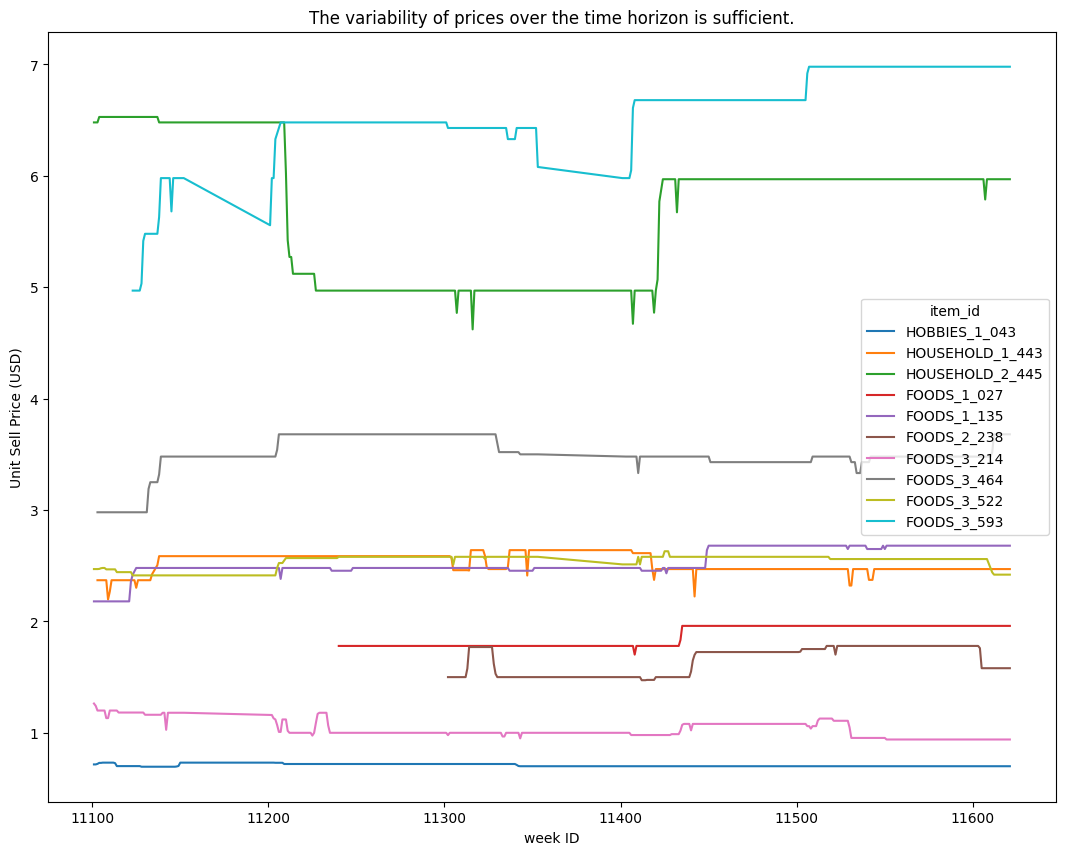

In [15]:
plot_df = prices.loc[prices["item_id"].isin(products_sample)]

plt.figure(figsize=(13,10))
sns.lineplot(data=plot_df,
             x="wm_yr_wk",
             y="sell_price",
             hue="item_id",
             errorbar=None)
plt.xlabel("week ID")
plt.ylabel("Unit Sell Price (USD)")
plt.title("The variability of prices over the time horizon is sufficient.")
plt.plot()

In [16]:
standard_deviations = prices[["item_id","sell_price"]].groupby(by="item_id").std().reset_index()

In [17]:
standard_deviations

,item_id,sell_price
0,FOODS_1_001,0.116225
1,FOODS_1_002,0.485684
2,FOODS_1_003,0.156082
3,FOODS_1_004,0.106627
4,FOODS_1_005,0.196211
...,...,...
3044,HOUSEHOLD_2_512,0.026996
3045,HOUSEHOLD_2_513,0.000000
3046,HOUSEHOLD_2_514,0.916503
3047,HOUSEHOLD_2_515,0.027617


In [18]:
standard_deviations["category"] = standard_deviations["item_id"].str.extract(r'(HOUSEHOLD|FOODS|HOBBIES)')
standard_deviations.groupby('category').median(numeric_only=True).reset_index()

,category,sell_price
0,FOODS,0.126944
1,HOBBIES,0.100428
2,HOUSEHOLD,0.125474


Is there a trivial pattern in food stamp days?

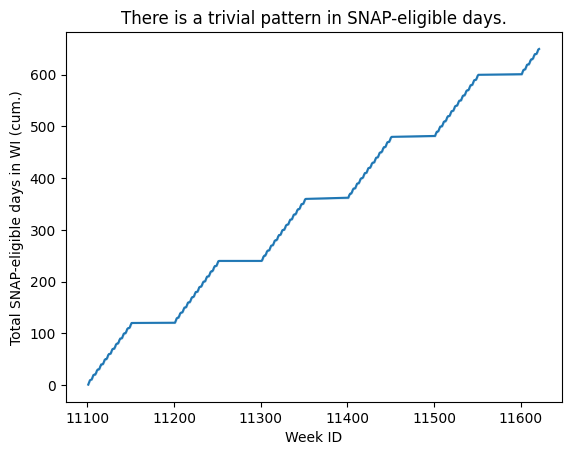

In [19]:
# to plot binary variable, cumulative sum is used
sns.lineplot(x=calendar["wm_yr_wk"], y=calendar.snap_WI.cumsum())
plt.ylabel("Total SNAP-eligible days in WI (cum.)")
plt.xlabel("Week ID")
plt.title("There is a trivial pattern in SNAP-eligible days.")
plt.show()

Do SNAP-eligible days induce higher demand?

In [20]:
snap_days_wi = calendar.loc[calendar.snap_WI == 1,"d"].values
snap_wi_sales = unit_sales.loc[unit_sales.state_id =="WI", [col for col in unit_sales.columns if (col in snap_days_wi)]]
nonsnap_wi_sales = unit_sales.loc[unit_sales.state_id =="WI", [col for col in unit_sales.columns if ((col not in snap_days_wi) and col.startswith("d_"))]]
print(f"The average demand on SNAP-eligible days in WI is {np.mean(snap_wi_sales.sum(axis=0)):.2f}.")
print(f"The average demand on non SNAP-eligible days in WI is {np.mean(nonsnap_wi_sales.sum(axis=0)):.2f}.")

The average demand on SNAP-eligible days in WI is 10832.66.
The average demand on non SNAP-eligible days in WI is 8892.50.


Plot the demand-price curve to test the validity of linear assumption

In [21]:
merged_df = calendar.merge(prices, how="left", on="wm_yr_wk")

merged_df["category"] = merged_df["item_id"].str.extract(r'(HOUSEHOLD|FOODS|HOBBIES)')

In [22]:
merged_df.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,store_id,item_id,sell_price,category
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,CA_1,HOBBIES_1_008,0.46,HOBBIES
1,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,CA_1,HOBBIES_1_009,1.56,HOBBIES
2,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,CA_1,HOBBIES_1_010,3.17,HOBBIES
3,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,CA_1,HOBBIES_1_012,5.98,HOBBIES
4,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,CA_1,HOBBIES_1_015,0.70,HOBBIES


In [23]:
merged_df = merged_df.loc[merged_df.category == 'FOODS',:]

In [24]:
p = merged_df.groupby(by="d")["sell_price"].mean()

# sort by date
p = p.iloc[sorted(range(len(p)), key=lambda i: int(p.index[i].split("_")[1]))]

In [25]:
unit_sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [26]:
# get product category-level demand for FOODS per day
foods_demand = unit_sales.loc[unit_sales.cat_id == 'FOODS',["cat_id"] + [col for col in unit_sales.columns if col.startswith("d_")]]
q = foods_demand.iloc[:,1:].mean().values

In [27]:
foods_demand

,cat_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
1612,FOODS,3,0,0,1,4,2,0,2,0,...,2,3,1,0,0,0,1,0,0,0
1613,FOODS,0,1,0,1,1,1,0,0,0,...,2,1,0,1,1,1,0,1,1,2
1614,FOODS,0,0,0,0,1,3,1,1,1,...,2,0,0,0,0,0,2,2,0,1
1615,FOODS,0,0,0,0,0,0,0,0,0,...,5,6,2,5,1,2,1,1,3,4
1616,FOODS,3,9,3,3,0,2,1,2,1,...,2,1,11,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS,0,0,2,2,0,3,1,4,1,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS,0,0,0,0,0,5,0,1,1,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS,0,6,0,2,2,4,1,8,5,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS,0,0,0,0,0,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0


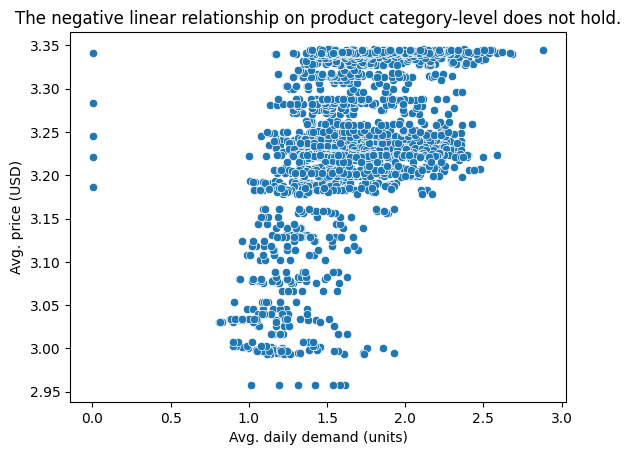

In [28]:
# the prices dataframe contains data up to d_1969
sns.scatterplot(x = q, y = p[0:len(q)])
plt.xlabel("Avg. daily demand (units)")
plt.ylabel("Avg. price (USD)")
plt.title("The negative linear relationship on product category-level does not hold.")
plt.show()

Does the negative linear price-demand relationship hold on department-level?

In [31]:
pd.unique(unit_sales.loc[unit_sales.cat_id=="FOODS","dept_id"])

array(['FOODS_1', 'FOODS_2', 'FOODS_3'], dtype=object)

In [44]:
# get product category-level demand for FOODS per day
foods_demand = unit_sales.loc[unit_sales.cat_id == 'FOODS',["dept_id"] + [col for col in unit_sales.columns if col.startswith("d_")]]
q = foods_demand.groupby(by=["dept_id"]).mean()

In [37]:
merged_df = calendar.merge(prices, how="left", on="wm_yr_wk")
merged_df = merged_df[merged_df.item_id.str.startswith("FOODS")]
merged_df["dept_id"] = merged_df["item_id"].str.extract(r'(FOODS_1|FOODS_2|FOODS_3)')

In [40]:
p = (
    merged_df
    .groupby(by=["dept_id", "d"])["sell_price"]
    .mean()
    .reset_index()
    .assign(d_num=lambda df: df["d"].str.extract(r'(\d+)').astype(int))
    .sort_values(["dept_id", "d_num"])
    .drop(columns="d_num")
)

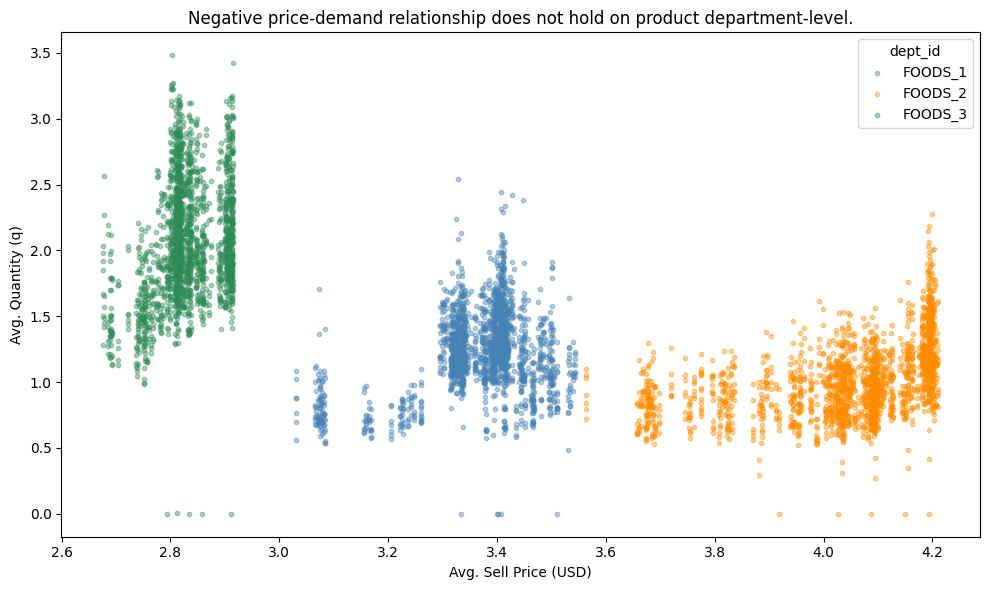

In [48]:
import matplotlib.pyplot as plt

# Melt q from wide to long
q_long = q.reset_index().melt(id_vars="dept_id", var_name="d", value_name="quantity")

# Merge p and q on dept_id + d
plot_df = p.merge(q_long, on=["dept_id", "d"])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"FOODS_1": "steelblue", "FOODS_2": "darkorange", "FOODS_3": "seagreen"}

for dept, group in plot_df.groupby("dept_id"):
    ax.scatter(group["sell_price"], group["quantity"], 
               label=dept, color=colors[dept], alpha=0.4, s=10)

ax.set_xlabel("Avg. Sell Price (USD)")
ax.set_ylabel("Avg. Quantity (q)")
ax.set_title("Negative price-demand relationship does not hold on product department-level.")
ax.legend(title="dept_id")
plt.tight_layout()
plt.show()

Does the negative price-demand relationship hold for products with the longest history?

In [53]:
unit_sales[["item_id"] + [col for col in unit_sales.columns if col.startswith("d_")]]

,item_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001,0,0,0,0,0,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002,0,0,0,0,0,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003,0,0,0,0,0,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004,0,0,0,0,0,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005,0,0,0,0,0,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS_3_823,0,0,2,2,0,3,1,4,1,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS_3_824,0,0,0,0,0,5,0,1,1,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS_3_825,0,6,0,2,2,4,1,8,5,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS_3_826,0,0,0,0,0,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0


In [56]:
unit_sales_item = unit_sales[["item_id"] + [col for col in unit_sales.columns if col.startswith("d_")]].groupby(by=["item_id"]).sum().reset_index()

In [58]:
unit_sales_item = unit_sales_item.loc[unit_sales_item.item_id.str.startswith("FOODS")]

In [60]:
d_cols = [c for c in unit_sales_item.columns if c.startswith("d_")]

nonzero_days = (
    unit_sales_item[["item_id"] + d_cols]
    .set_index("item_id")
    .gt(0)
    .sum(axis=1)
    .rename("nonzero_demand_days")
    .reset_index()
)

In [64]:
nonzero_days.sort_values(by="nonzero_demand_days",ascending=False,inplace=True)

In [65]:
nonzero_days

,item_id,nonzero_demand_days
692,FOODS_3_080,1940
1167,FOODS_3_555,1940
1198,FOODS_3_586,1940
989,FOODS_3_377,1939
864,FOODS_3_252,1939
...,...,...
1214,FOODS_3_602,359
616,FOODS_3_003,348
1078,FOODS_3_466,275
1175,FOODS_3_563,271


In [72]:
top3 = nonzero_days.iloc[0:3,0].values

In [75]:
# get department-level demand for FOODS per day
foods_demand = unit_sales.loc[unit_sales.cat_id == 'FOODS',["item_id"] + [col for col in unit_sales.columns if col.startswith("d_")]]
q = foods_demand.groupby(by=["item_id"]).mean().reset_index()

In [82]:
q = q[q["item_id"].isin(top3)]

In [83]:
merged_df = calendar.merge(prices, how="left", on="wm_yr_wk")
merged_df = merged_df[merged_df.item_id.isin(top3)]

In [84]:
p = (
    merged_df
    .groupby(by=["item_id", "d"])["sell_price"]
    .mean()
    .reset_index()
    .assign(d_num=lambda df: df["d"].str.extract(r'(\d+)').astype(int))
    .sort_values(["item_id", "d_num"])
    .drop(columns="d_num")
)

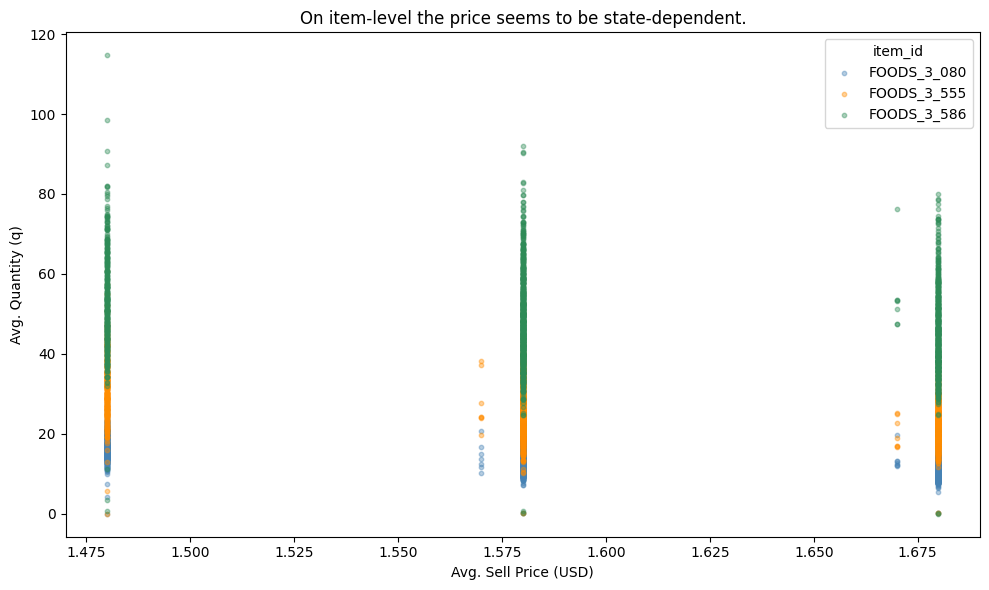

In [87]:
import matplotlib.pyplot as plt

# Melt q from wide to long
q_long = q.reset_index().melt(id_vars="item_id", var_name="d", value_name="quantity")

# Merge p and q on dept_id + d
plot_df = p.merge(q_long, on=["item_id", "d"])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"FOODS_3_080": "steelblue", "FOODS_3_555": "darkorange", "FOODS_3_586": "seagreen"}

for dept, group in plot_df.groupby("item_id"):
    ax.scatter(group["sell_price"], group["quantity"], 
               label=dept, color=colors[dept], alpha=0.4, s=10)

ax.set_xlabel("Avg. Sell Price (USD)")
ax.set_ylabel("Avg. Quantity (q)")
ax.set_title("On item-level the price seems to be state-dependent.")
ax.legend(title="item_id")
plt.tight_layout()
plt.show()

In [94]:
unique_prices = (
    prices[prices["item_id"].str.startswith("FOODS")]
    .groupby(["store_id", "item_id"])["sell_price"]
    .nunique()
    .rename("n_unique_prices")
    .reset_index()
    .sort_values("n_unique_prices", ascending=False)
)

unique_prices.head(10)

,store_id,item_id,n_unique_prices
5841,TX_1,FOODS_1_095,21
8715,TX_3,FOODS_1_095,21
10185,WI_1,FOODS_1_129,20
93,CA_1,FOODS_1_095,18
4404,CA_4,FOODS_1_095,18
1530,CA_2,FOODS_1_095,18
7278,TX_2,FOODS_1_095,18
13059,WI_3,FOODS_1_129,18
11622,WI_2,FOODS_1_129,18
8716,TX_3,FOODS_1_096,17


In [89]:
unit_sales

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,2,2,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,6,0,2,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0


In [125]:
# get department-level demand for FOODS per day
foods_demand = unit_sales[unit_sales.state_id == "TX"]
foods_demand = foods_demand.loc[foods_demand.cat_id == 'FOODS',["item_id"] + [col for col in foods_demand.columns if col.startswith("d_")]]
q = foods_demand.groupby(by=["item_id"]).mean().reset_index()

In [126]:
product_list = ["FOODS_1_095","FOODS_1_096","FOODS_1_129"]
# product_list = ["FOODS_1_095","FOODS_1_096"]

In [127]:
q = q[q.item_id.isin(product_list)]

In [ ]:
merged_df = calendar.merge(prices, how="left", on="wm_yr_wk")
merged_df = merged_df[merged_df.item_id.isin(product_list)]

In [ ]:
p = (
    merged_df
    .groupby(by=["item_id", "d"])["sell_price"]
    .mean()
    .reset_index()
    .assign(d_num=lambda df: df["d"].str.extract(r'(\d+)').astype(int))
    .sort_values(["item_id", "d_num"])
    .drop(columns="d_num")
)

In [ ]:
p

,item_id,d,sell_price
0,FOODS_1_095,d_1,3.368
1081,FOODS_1_095,d_2,3.368
1192,FOODS_1_095,d_3,3.368
1303,FOODS_1_095,d_4,3.368
1414,FOODS_1_095,d_5,3.368
...,...,...,...
3042,FOODS_1_096,d_1965,6.459
3043,FOODS_1_096,d_1966,6.459
3044,FOODS_1_096,d_1967,6.459
3045,FOODS_1_096,d_1968,6.459


In [ ]:
q_long = q.reset_index().melt(id_vars="item_id", var_name="d", value_name="quantity")
q_long

,item_id,d,quantity
0,FOODS_1_095,index,93.0
1,FOODS_1_096,index,94.0
2,FOODS_1_095,d_1,0.0
3,FOODS_1_096,d_1,1.0
4,FOODS_1_095,d_2,1.0
...,...,...,...
3879,FOODS_1_096,d_1939,5.0
3880,FOODS_1_095,d_1940,0.0
3881,FOODS_1_096,d_1940,10.0
3882,FOODS_1_095,d_1941,0.0


In [ ]:
pq = p.merge(q_long,how="left", on=["d","item_id"])
pq

,item_id,d,sell_price,quantity
0,FOODS_1_095,d_1,3.368,0.0
1,FOODS_1_095,d_2,3.368,1.0
2,FOODS_1_095,d_3,3.368,1.0
3,FOODS_1_095,d_4,3.368,0.0
4,FOODS_1_095,d_5,3.368,1.0
...,...,...,...,...
3933,FOODS_1_096,d_1965,6.459,NaN
3934,FOODS_1_096,d_1966,6.459,NaN
3935,FOODS_1_096,d_1967,6.459,NaN
3936,FOODS_1_096,d_1968,6.459,NaN


In [ ]:
prices_demand = pq.drop(columns=["d"], inplace=False).groupby(by=["item_id","sell_price"]).mean().reset_index()

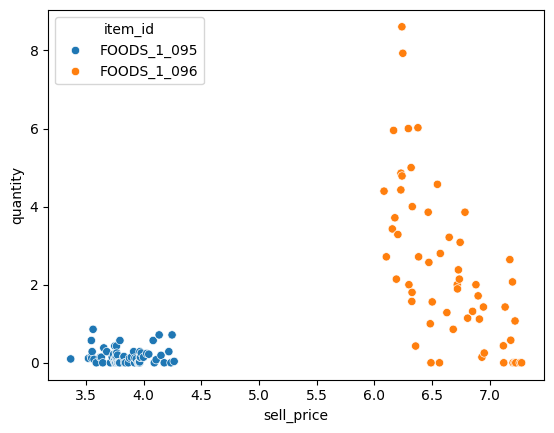

In [ ]:
sns.scatterplot(data=prices_demand, x="sell_price", y="quantity", hue="item_id")
plt.show()

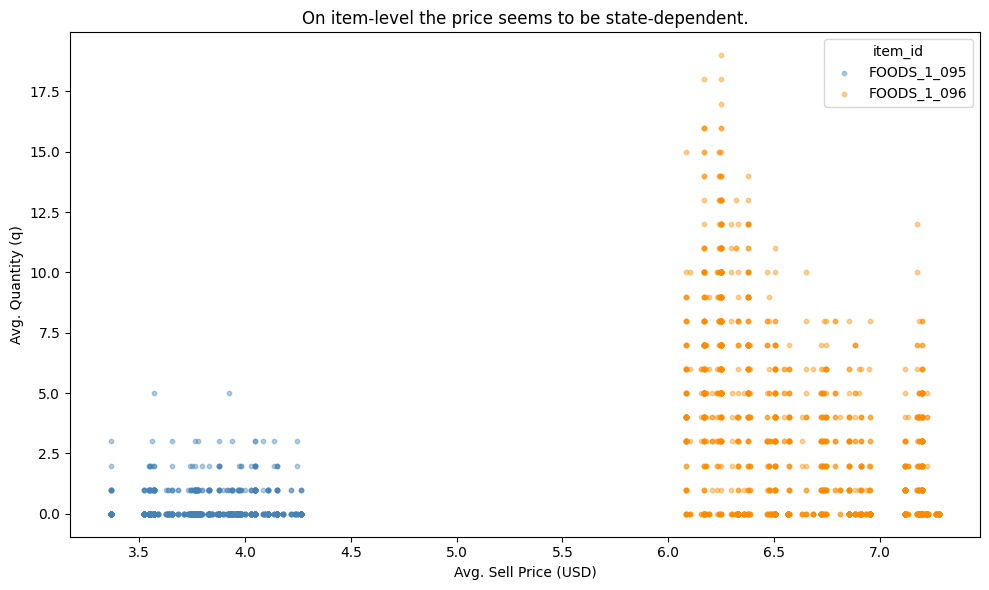

In [114]:
import matplotlib.pyplot as plt

# Melt q from wide to long
q_long = q.reset_index().melt(id_vars="item_id", var_name="d", value_name="quantity")

# Merge p and q on dept_id + d
plot_df = p.merge(q_long, on=["item_id", "d"])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"FOODS_1_095": "steelblue", "FOODS_1_096": "darkorange", "FOODS_1_129": "seagreen"}

for dept, group in plot_df.groupby("item_id"):
    ax.scatter(group["sell_price"], group["quantity"], 
               label=dept, color=colors[dept], alpha=0.4, s=10)

ax.set_xlabel("Avg. Sell Price (USD)")
ax.set_ylabel("Avg. Quantity (q)")
ax.set_title("On item-level the price seems to be state-dependent.")
ax.legend(title="item_id")
plt.tight_layout()
plt.show()

With a price granularity of 0.15, all actions (prices) have non-zero granularity. Therefore the assumption behind Offline RL could be satisfied.

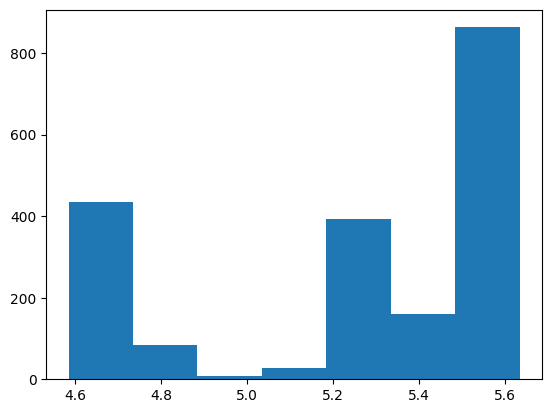

In [ ]:
lo, hi = min(p), max(p)
bins = np.arange(lo, hi + 0.15, 0.15)

plt.hist(p, bins=bins)
plt.show()

# Exploratory Analysis of Online Retail II Dataset (UCI)

In [ ]:
# read in data
online_retail = pd.read_excel("../data/online_retail_ii/online_retail_II.xlsx")

In [ ]:
# run .info() (pandas equivalent of str)
online_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
# look at top and bottom of data
online_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
online_retail.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


In [8]:
# check the packaging
print(f"The shape of the online retail II dataset is {online_retail.shape}")

The shape of the online retail II dataset is (525461, 8)


In [13]:
# check your n-s
print(f"Number of unique invoices:{online_retail["Invoice"].unique().shape[0]}")
print(f"Number of unique countries:{online_retail["Country"].unique().shape[0]}")
print(f"Number of unique products:{online_retail["StockCode"].unique().shape[0]}")

Number of unique invoices:28816
Number of unique countries:40
Number of unique products:4632


In [14]:
print(f"Date range available: {online_retail["InvoiceDate"].min()} to {online_retail["InvoiceDate"].max()}")

Date range available: 2009-12-01 07:45:00 to 2010-12-09 20:01:00


In [18]:
online_retail.groupby(by=["StockCode"]).count().iloc[:,0]

StockCode
10002           327
10080             7
10109             2
10120            49
10125            87
               ... 
gift_0001_60      2
gift_0001_70      3
gift_0001_80      4
gift_0001_90      2
m                 4
Name: Invoice, Length: 4632, dtype: int64

In [24]:
product_counts = online_retail.groupby(by=["StockCode"]).count().iloc[:,0]
available_prod_hist = product_counts.value_counts()

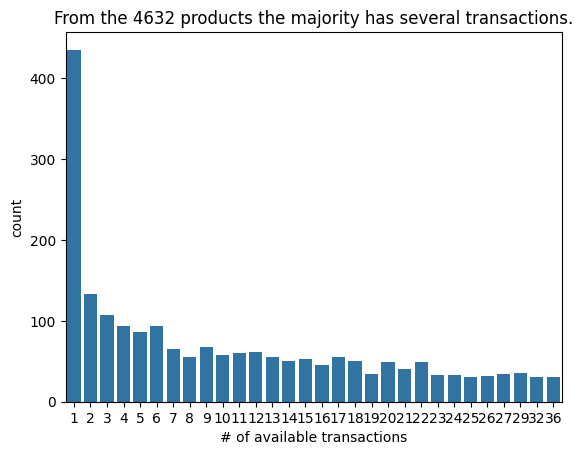

In [30]:
sns.barplot(x=available_prod_hist.index[:30], y=available_prod_hist[:30])
plt.title("From the 4632 products the majority has several transactions.")
plt.xlabel("# of available transactions")
plt.show()

In [35]:
num_above_30 = product_counts[product_counts>30].shape[0]
print(f"Number of products with atleast 30 transactions: {num_above_30}")

Number of products with atleast 30 transactions: 2592


In [36]:
prod_above_30 = product_counts[product_counts>30].index
prod_above_30

Index([         10002,          10120,          10125,          10133,
                10134,          10135,          11001,          15034,
                15036,          15039,
       ...
             '90214S',       'ADJUST', 'BANK CHARGES',           'C2',
                  'D',     'DCGS0058',          'DOT',            'M',
               'POST',            'S'],
      dtype='object', name='StockCode', length=2592)

In [40]:
chosen_products = list(pd.Series(prod_above_30).sample(10))

In [44]:
plot_df = online_retail.loc[online_retail["StockCode"].isin(chosen_products),["StockCode","Price"]]

In [45]:
plot_df

,StockCode,Price
590,21173,1.65
1620,22215,8.50
1655,22215,8.50
1959,21173,4.30
3295,82615,2.55
...,...,...
523226,22572,0.85
523977,22572,1.66
524536,22572,0.85
524851,22664,4.21


c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 76.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 85.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 94.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 94.9% of the points cannot be placed; you may want to decrease the size of the markers or use strip

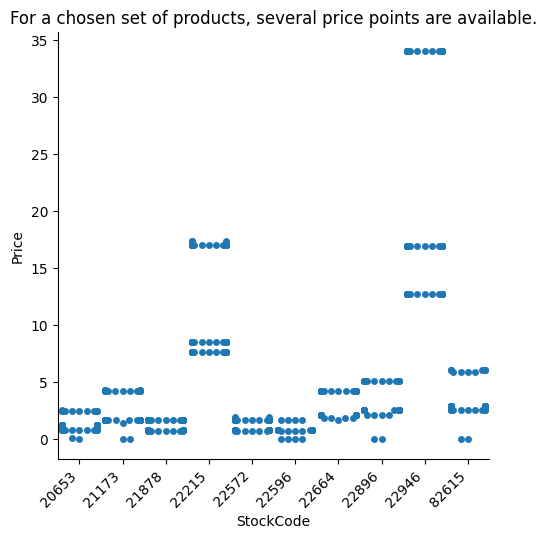

In [65]:
g = sns.catplot(data=plot_df, x="StockCode", y="Price",kind='swarm')

for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.title("For a chosen set of products, several price points are available.")
plt.show()